<a href="https://colab.research.google.com/github/cs24dse023-netizen/CSL701-cs23_Machine-Learning-Lab/blob/main/ML_Exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Name: Sandesh Deepak Kaskar
RollNo:Cs23

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# For displaying tables neatly
import pandas as pd

# Reproducibility
np.random.seed(42)

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.0.2
Pandas version: 2.2.2


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
# Task 2: Load and Inspect the Dataset

import pandas as pd
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(file_name)

# Display first 5 records
print("First 5 records:")
display(df.head())

# Display number of rows and columns
print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Identify numerical and categorical attributes
numerical_attributes = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_attributes = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Attributes:")
print(numerical_attributes)

print("\nCategorical Attributes:")
print(categorical_attributes)

# Separate target variable
y = df["selling_price"]

# Predictor variables
X = df.drop(columns=["selling_price"])

print("\nTarget Variable: selling_price")
print("Target shape:", y.shape)
print("Predictor shape:", X.shape)

Saving cardekho_dataset.csv to cardekho_dataset (4).csv
First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows: 15411
Number of columns: 14

Numerical Attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical Attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target Variable: selling_price
Target shape: (15411,)
Predictor shape: (15411, 13)


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Task 3: Check and Handle Missing Data

# Count missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

# Total missing values
total_missing = df.isnull().sum().sum()
print("\nTotal missing values:", total_missing)

# Handle missing values
if total_missing > 0:
    df = df.dropna()
    print("\nMissing rows removed.")
else:
    print("\nNo missing values found. No preprocessing required.")

# Verify final dataset
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

print("\nFinal total missing values:",
      df.isnull().sum().sum())

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0

No missing values found. No preprocessing required.

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Final total missing values: 0


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# Task 4: Select and Prepare Features

# Display all available attributes
print("All available attributes:")
print(df.columns.tolist())

# Car_Name is not used because it contains many unique car names
# and would create too many dummy variables.
# We also exclude the index column.

# Select meaningful predictor variables
selected_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "fuel_type",
    "seller_type",
    "transmission_type"
]

# Create predictor matrix X
X = df[selected_features]

# Create target vector y
y = df["selling_price"]

# Display selected features
print("\nSelected Predictor Features:")
print(selected_features)

print("\nPredictor Matrix X:")
display(X.head())

print("\nTarget Vector y:")
display(y.head())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nCar_Name handling: Excluded because it has high-cardinality categorical values.")

All available attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Selected Predictor Features:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_type', 'seller_type', 'transmission_type']

Predictor Matrix X:


,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type,seller_type,transmission_type
0,9,120000,19.70,796,46.30,5,Petrol,Individual,Manual
1,5,20000,18.90,1197,82.00,5,Petrol,Individual,Manual
2,11,60000,17.00,1197,80.00,5,Petrol,Individual,Manual
3,9,37000,20.92,998,67.10,5,Petrol,Individual,Manual
4,6,30000,22.77,1498,98.59,5,Diesel,Dealer,Manual



Target Vector y:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000



Shape of X: (15411, 9)
Shape of y: (15411,)

Car_Name handling: Excluded because it has high-cardinality categorical values.


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# Task 5: Encode Categorical Variables

# Identify categorical variables
categorical_features = [
    "fuel_type",
    "seller_type",
    "transmission_type"
]

print("Categorical Variables:")
print(categorical_features)

# Convert categorical variables into dummy/indicator variables
# drop_first=True avoids the dummy variable trap
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=float
)

# Verify that all predictors are numerical
print("\nData types after encoding:")
print(X_encoded.dtypes)

print("\nAre all predictors numerical?")
print(X_encoded.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all())

# Display transformed dataset
print("\nTransformed Dataset:")
display(X_encoded.head())

# Display final feature names
print("\nFinal Features:")
print(X_encoded.columns.tolist())

print("\nShape of transformed X:", X_encoded.shape)

Categorical Variables:
['fuel_type', 'seller_type', 'transmission_type']

Data types after encoding:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
transmission_type_Manual        float64
dtype: object

Are all predictors numerical?
True

Transformed Dataset:


,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,5,20000,18.90,1197,82.00,5,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,11,60000,17.00,1197,80.00,5,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,9,37000,20.92,998,67.10,5,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,6,30000,22.77,1498,98.59,5,1.0,0.0,0.0,0.0,0.0,0.0,1.0



Final Features:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual']

Shape of transformed X: (15411, 13)


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# Task 6: Perform Feature Engineering

# Create Car_Age using the existing vehicle_age column
df["Car_Age"] = df["vehicle_age"]

# Display several values
print("Sample Car_Age values:")
print(df[["vehicle_age", "Car_Age"]].head(10))

# Verify that the ages are reasonable
print("\nMinimum Car Age:", df["Car_Age"].min())
print("Maximum Car Age:", df["Car_Age"].max())

# Check whether Year column exists
if "Year" in df.columns:
    print("\nYear column is available.")
else:
    print("\nYear column is not available in this dataset.")
    print("The existing vehicle_age column is used as Car_Age.")

# Decision
print("\nDecision:")
print("The original vehicle_age column is not needed separately because")
print("Car_Age contains the same information. Therefore, vehicle_age can be removed.")

Sample Car_Age values:
   vehicle_age  Car_Age
0            9        9
1            5        5
2           11       11
3            9        9
4            6        6
5            8        8
6            8        8
7            3        3
8            2        2
9            4        4

Minimum Car Age: 0
Maximum Car Age: 29

Year column is not available in this dataset.
The existing vehicle_age column is used as Car_Age.

Decision:
The original vehicle_age column is not needed separately because
Car_Age contains the same information. Therefore, vehicle_age can be removed.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

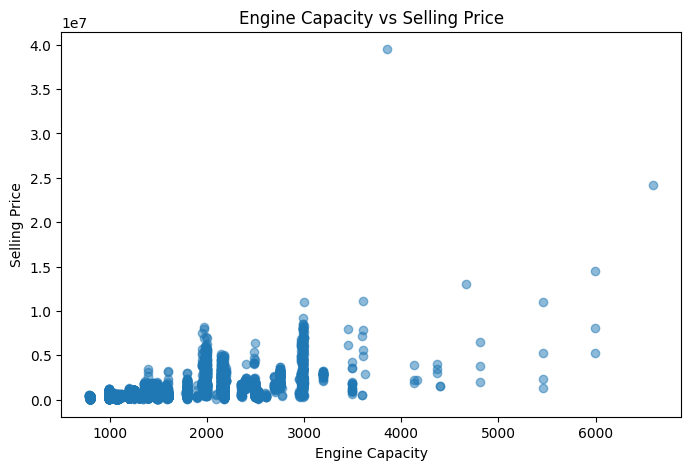

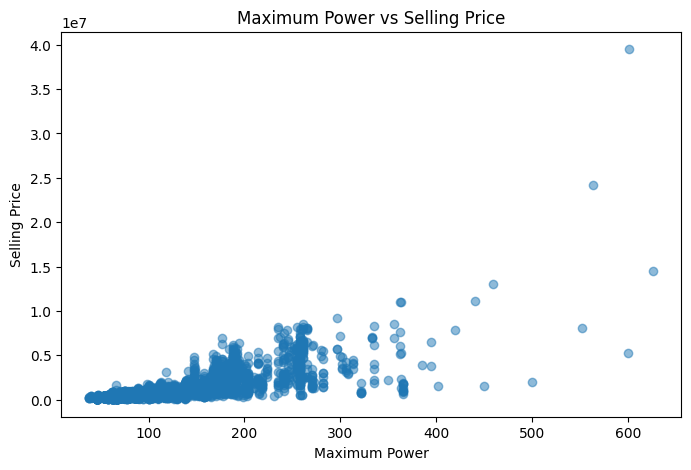

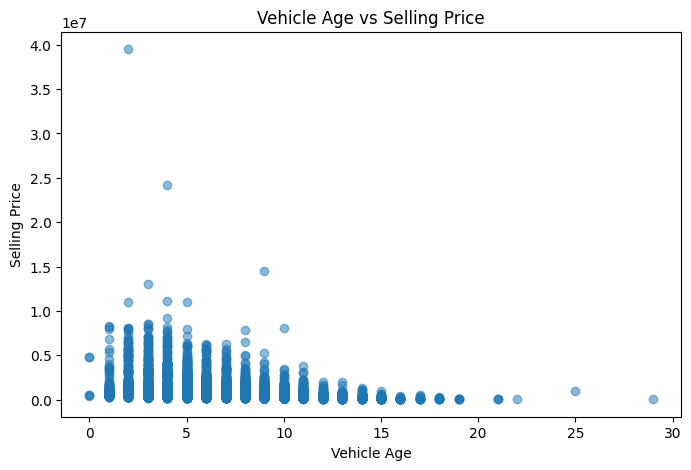


Observations:
1. Engine capacity generally has a positive relationship with selling price.
2. Maximum power generally has a positive relationship with selling price.
3. Vehicle age generally has a negative relationship with selling price.
4. The relationships are not perfectly linear because used-car prices depend on many factors.


In [ ]:
# Task 7: Perform Exploratory Data Analysis

import matplotlib.pyplot as plt

# Scatter plot 1: Engine vs Selling Price
plt.figure(figsize=(8, 5))
plt.scatter(df["engine"], df["selling_price"], alpha=0.5)
plt.xlabel("Engine Capacity")
plt.ylabel("Selling Price")
plt.title("Engine Capacity vs Selling Price")
plt.show()

# Scatter plot 2: Maximum Power vs Selling Price
plt.figure(figsize=(8, 5))
plt.scatter(df["max_power"], df["selling_price"], alpha=0.5)
plt.xlabel("Maximum Power")
plt.ylabel("Selling Price")
plt.title("Maximum Power vs Selling Price")
plt.show()

# Scatter plot 3: Vehicle Age vs Selling Price
plt.figure(figsize=(8, 5))
plt.scatter(df["vehicle_age"], df["selling_price"], alpha=0.5)
plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")
plt.title("Vehicle Age vs Selling Price")
plt.show()

# Observations
print("\nObservations:")
print("1. Engine capacity generally has a positive relationship with selling price.")
print("2. Maximum power generally has a positive relationship with selling price.")
print("3. Vehicle age generally has a negative relationship with selling price.")
print("4. The relationships are not perfectly linear because used-car prices depend on many factors.")

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# Task 8: Standardize Numerical Features

import numpy as np

# Numerical features to standardize
numerical_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# Create X and y
X = df[numerical_features].copy()
y = df["selling_price"].copy()

# 80:20 Train-Test Split
np.random.seed(42)

indices = np.random.permutation(len(X))
train_size = int(0.80 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

# Calculate mean and standard deviation using TRAINING data only
train_mean = X_train.mean()
train_std = X_train.std()

# Standardize training features
X_train[numerical_features] = (
    X_train[numerical_features] - train_mean
) / train_std

# Standardize testing features using TRAINING mean and std
X_test[numerical_features] = (
    X_test[numerical_features] - train_mean
) / train_std

# Display results
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining Mean:")
print(train_mean)

print("\nTraining Standard Deviation:")
print(train_std)

print("\nStandardized Training Data:")
display(X_train.head())

print("\nStandardized Testing Data:")
display(X_test.head())

print("\nTarget variable Selling_Price was NOT standardized.")

Training data shape: (12328, 6)
Testing data shape: (3083, 6)

Training Mean:
vehicle_age        6.032446
km_driven      55692.819598
mileage           19.691552
engine          1485.037395
max_power        100.516747
seats              5.326249
dtype: float64

Training Standard Deviation:
vehicle_age        3.018870
km_driven      54473.163748
mileage            4.172802
engine           518.296985
max_power         42.745688
seats              0.809603
dtype: float64

Standardized Training Data:


,vehicle_age,km_driven,mileage,engine,max_power,seats
3334,1.976751,0.317719,0.160192,-0.555738,-0.505706,-0.402974
10928,-0.673248,0.042354,1.844911,-0.457339,-0.620337,-0.402974
2518,0.320502,0.739946,0.258447,-0.457339,-0.275039,2.067371
11322,-1.666997,-0.939781,-0.309517,0.025010,0.440588,-0.402974
9394,1.645501,0.115785,0.002025,-1.329426,-1.268356,-0.402974



Standardized Testing Data:


,vehicle_age,km_driven,mileage,engine,max_power,seats
15384,-1.004497,-0.563448,-2.322552,1.279117,1.625503,-0.402974
147,0.651752,0.409508,-0.752864,0.931826,1.099368,-0.402974
1668,0.320502,0.124964,1.320084,-0.457339,-0.620337,-0.402974
11280,-0.341998,-0.563448,1.348841,-0.553809,-0.550155,0.832199
13650,-1.004497,-0.618521,-0.357446,-0.551879,-0.276443,-0.402974



Target variable Selling_Price was NOT standardized.


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# Task 9: Split the Dataset

import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of observations
n = len(df)

# Randomly shuffle indices
indices = np.random.permutation(n)

# Calculate 80% training size
train_size = int(0.80 * n)

# Split indices
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create training and testing datasets
X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

# Display number of observations
print("Total observations:", n)
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

# Display ratio
print("\nTraining ratio:", len(X_train) / n * 100, "%")
print("Testing ratio:", len(X_test) / n * 100, "%")

Total observations: 15411
Training observations: 12328
Testing observations: 3083

Training ratio: 79.99480890273182 %
Testing ratio: 20.005191097268185 %


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# Task 10: Construct the Feature Matrix

# Convert training and testing data into NumPy matrices
Xtrain = X_train.to_numpy(dtype=float)
ytrain = y_train.to_numpy(dtype=float)

Xtest = X_test.to_numpy(dtype=float)
ytest = y_test.to_numpy(dtype=float)

# Display number of rows and predictor columns
print("Training Feature Matrix (Xtrain):")
print("Rows:", Xtrain.shape[0])
print("Predictor Columns:", Xtrain.shape[1])
print("Shape:", Xtrain.shape)

print("\nTraining Target Vector (ytrain):")
print("Rows:", ytrain.shape[0])
print("Shape:", ytrain.shape)

print("\nTesting Feature Matrix (Xtest):")
print("Rows:", Xtest.shape[0])
print("Predictor Columns:", Xtest.shape[1])
print("Shape:", Xtest.shape)

print("\nTesting Target Vector (ytest):")
print("Rows:", ytest.shape[0])
print("Shape:", ytest.shape)

# Display first 5 rows
print("\nFirst 5 rows of Xtrain:")
print(Xtrain[:5])

print("\nFirst 5 values of ytrain:")
print(ytrain[:5])

Training Feature Matrix (Xtrain):
Rows: 12328
Predictor Columns: 6
Shape: (12328, 6)

Training Target Vector (ytrain):
Rows: 12328
Shape: (12328,)

Testing Feature Matrix (Xtest):
Rows: 3083
Predictor Columns: 6
Shape: (3083, 6)

Testing Target Vector (ytest):
Rows: 3083
Shape: (3083,)

First 5 rows of Xtrain:
[[1.2000e+01 7.3000e+04 2.0360e+01 1.1970e+03 7.8900e+01 5.0000e+00]
 [4.0000e+00 5.8000e+04 2.7390e+01 1.2480e+03 7.4000e+01 5.0000e+00]
 [7.0000e+00 9.6000e+04 2.0770e+01 1.2480e+03 8.8760e+01 7.0000e+00]
 [1.0000e+00 4.5000e+03 1.8400e+01 1.4980e+03 1.1935e+02 5.0000e+00]
 [1.1000e+01 6.2000e+04 1.9700e+01 7.9600e+02 4.6300e+01 5.0000e+00]]

First 5 values of ytrain:
[ 190000.  600000.  665000. 1570000.  160000.]


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# Task 11: Add the Bias/Intercept Term

# Add a column of 1.0 to the beginning of the training matrix
Xtrain_bias = np.column_stack((
    np.ones(Xtrain.shape[0]),
    Xtrain
))

# Add a column of 1.0 to the beginning of the testing matrix
Xtest_bias = np.column_stack((
    np.ones(Xtest.shape[0]),
    Xtest
))

# Display dimensions
print("Original Xtrain shape:", Xtrain.shape)
print("Xtrain with bias shape:", Xtrain_bias.shape)

print("\nOriginal Xtest shape:", Xtest.shape)
print("Xtest with bias shape:", Xtest_bias.shape)

# Display first few rows
print("\nFirst 5 rows of Xtrain with bias:")
print(Xtrain_bias[:5])

print("\nFirst 5 rows of Xtest with bias:")
print(Xtest_bias[:5])

print("\nThe first column containing 1.0 represents the intercept (β0).")

Original Xtrain shape: (12328, 6)
Xtrain with bias shape: (12328, 7)

Original Xtest shape: (3083, 6)
Xtest with bias shape: (3083, 7)

First 5 rows of Xtrain with bias:
[[1.0000e+00 1.2000e+01 7.3000e+04 2.0360e+01 1.1970e+03 7.8900e+01
  5.0000e+00]
 [1.0000e+00 4.0000e+00 5.8000e+04 2.7390e+01 1.2480e+03 7.4000e+01
  5.0000e+00]
 [1.0000e+00 7.0000e+00 9.6000e+04 2.0770e+01 1.2480e+03 8.8760e+01
  7.0000e+00]
 [1.0000e+00 1.0000e+00 4.5000e+03 1.8400e+01 1.4980e+03 1.1935e+02
  5.0000e+00]
 [1.0000e+00 1.1000e+01 6.2000e+04 1.9700e+01 7.9600e+02 4.6300e+01
  5.0000e+00]]

First 5 rows of Xtest with bias:
[[1.0000e+00 3.0000e+00 2.5000e+04 1.0000e+01 2.1480e+03 1.7000e+02
  5.0000e+00]
 [1.0000e+00 8.0000e+00 7.8000e+04 1.6550e+01 1.9680e+03 1.4751e+02
  5.0000e+00]
 [1.0000e+00 7.0000e+00 6.2500e+04 2.5200e+01 1.2480e+03 7.4000e+01
  5.0000e+00]
 [1.0000e+00 5.0000e+00 2.5000e+04 2.5320e+01 1.1980e+03 7.7000e+01
  6.0000e+00]
 [1.0000e+00 3.0000e+00 2.2000e+04 1.8200e+01 1.1990e+03 

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
# Task 12: Implement the OLS Function

def OLS(X, y):
    # Calculate X^T X
    XTX = X.T @ X

    # Calculate X^T y
    XTy = X.T @ y

    # Calculate beta = (X^T X)^-1 X^T y
    beta = np.linalg.inv(XTX) @ XTy

    # Return coefficient vector
    return beta


# Apply OLS to training data
beta = OLS(Xtrain_bias, ytrain)

# Display regression coefficients
print("Regression Coefficient Vector (β):")
print(beta)

print("\nNumber of coefficients:", len(beta))

Regression Coefficient Vector (β):
[-7.65870856e+05 -6.50147792e+04 -6.77550257e-01  1.37530571e+04
  7.58158512e+01  1.57543776e+04  8.57129320e+02]

Number of coefficients: 7


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# Task 13: Check Matrix Singularity

# Calculate X^T X
XTX = Xtrain_bias.T @ Xtrain_bias

# Calculate determinant of X^T X
det_XTX = np.linalg.det(XTX)

print("Determinant of X^T X:", det_XTX)

# Check whether the matrix is singular or nearly singular
if np.isclose(det_XTX, 0):
    print("\nX^T X is singular or nearly singular.")
    print("The selected features may have redundancy or multicollinearity.")
else:
    print("\nX^T X is non-singular.")
    print("The selected feature set does not produce a singular matrix.")

# Check condition number for additional multicollinearity information
condition_number = np.linalg.cond(XTX)

print("\nCondition Number:", condition_number)

if condition_number > 1e10:
    print("Observation: High condition number indicates possible multicollinearity.")
else:
    print("Observation: No severe multicollinearity is indicated by the condition number.")

Determinant of X^T X: 4.812491773078243e+47

X^T X is non-singular.
The selected feature set does not produce a singular matrix.

Condition Number: 1222348027225.2598
Observation: High condition number indicates possible multicollinearity.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# Task 14: Train the Regression Model

# Apply OLS to training data
beta = OLS(Xtrain_bias, ytrain)

# Display intercept
print("Intercept (β0):")
print(beta[0])

# Feature names
feature_names = ["Intercept"] + X_encoded.columns.tolist()

# Display coefficients with corresponding features
print("\nRegression Coefficients:")
for feature, coefficient in zip(feature_names, beta):
    print(f"{feature}: {coefficient:.4f}")

Intercept (β0):
-765870.855685398

Regression Coefficients:
Intercept: -765870.8557
vehicle_age: -65014.7792
km_driven: -0.6776
mileage: 13753.0571
engine: 75.8159
max_power: 15754.3776
seats: 857.1293


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
# Task 15: Interpret the Regression Coefficients

# Make sure beta is calculated from the current training matrix
beta = OLS(Xtrain_bias, ytrain)

# Create feature names based on the actual number of predictors
feature_names = ["Intercept"] + [
    f"Feature_{i+1}" for i in range(Xtrain_bias.shape[1] - 1)
]

# Create coefficient table
coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta
})

# Identify positive or negative effect
coef_table["Effect"] = np.where(
    coef_table["Coefficient"] >= 0,
    "Positive",
    "Negative"
)

# Absolute coefficient for comparing influence
coef_table["Absolute_Coefficient"] = np.abs(
    coef_table["Coefficient"]
)

# Sort by coefficient magnitude
coef_table = coef_table.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Regression Coefficient Interpretation:")
display(coef_table)

# Interpret each coefficient
print("\nInterpretation:")
for _, row in coef_table.iterrows():

    feature = row["Feature"]
    coefficient = row["Coefficient"]

    if feature == "Intercept":
        print(f"{feature}: {coefficient:.2f} (intercept)")

    elif coefficient > 0:
        print(
            f"{feature}: Positive coefficient ({coefficient:.2f}) - "
            "an increase in this feature increases the predicted selling price."
        )

    else:
        print(
            f"{feature}: Negative coefficient ({coefficient:.2f}) - "
            "an increase in this feature decreases the predicted selling price."
        )

print("\nObservation:")
print("A larger absolute coefficient indicates a relatively greater influence")
print("on the predicted selling price.")

print("\nSince the numerical features were standardized, their coefficients")
print("represent the change in predicted selling price for a one-standard-")
print("deviation increase in that feature, keeping other features constant.")

Regression Coefficient Interpretation:


,Feature,Coefficient,Effect,Absolute_Coefficient
0,Intercept,-765870.855685,Negative,765870.855685
1,Feature_1,-65014.779175,Negative,65014.779175
5,Feature_5,15754.377629,Positive,15754.377629
3,Feature_3,13753.057078,Positive,13753.057078
6,Feature_6,857.129320,Positive,857.129320
4,Feature_4,75.815851,Positive,75.815851
2,Feature_2,-0.677550,Negative,0.677550



Interpretation:
Intercept: -765870.86 (intercept)
Feature_1: Negative coefficient (-65014.78) - an increase in this feature decreases the predicted selling price.
Feature_5: Positive coefficient (15754.38) - an increase in this feature increases the predicted selling price.
Feature_3: Positive coefficient (13753.06) - an increase in this feature increases the predicted selling price.
Feature_6: Positive coefficient (857.13) - an increase in this feature increases the predicted selling price.
Feature_4: Positive coefficient (75.82) - an increase in this feature increases the predicted selling price.
Feature_2: Negative coefficient (-0.68) - an increase in this feature decreases the predicted selling price.

Observation:
A larger absolute coefficient indicates a relatively greater influence
on the predicted selling price.

Since the numerical features were standardized, their coefficients
represent the change in predicted selling price for a one-standard-
deviation increase in that feat

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# Task 16: Predict Selling Prices

# Predict selling prices using:
# y_pred = Xtest_bias × beta

y_pred = Xtest_bias @ beta

# Create comparison table
comparison = pd.DataFrame({
    "Actual Selling Price": ytest,
    "Predicted Selling Price": y_pred
})

# Display first 10 predictions
print("Actual vs Predicted Selling Prices:")
display(comparison.head(10))

# Display prediction equation information
print("\nNumber of test observations:", len(ytest))
print("Number of predictions:", len(y_pred))

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4450000.0,2.005059e+06
1,1290000.0,1.366195e+06
2,485000.0,3.479836e+05
3,400000.0,5.494011e+05
4,800000.0,7.670865e+05
5,150000.0,-6.138200e+05
6,650000.0,8.423696e+05
7,325000.0,-1.570072e+05
8,300000.0,4.044672e+05
9,925000.0,7.762169e+05



Number of test observations: 3083
Number of predictions: 3083


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# Task 17: Calculate Prediction Errors and RSS

# Calculate residuals
residuals = ytest - y_pred

# Calculate Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

# Display sample residuals
print("Sample Prediction Errors (Residuals):")
print(residuals[:10])

# Display RSS
print("\nResidual Sum of Squares (RSS):")
print(f"{RSS:,.2f}")

# Interpretation
print("\nInterpretation:")
print("RSS represents the total squared prediction error of the model.")
print("A lower RSS indicates that the predicted selling prices are closer")
print("to the actual selling prices, meaning the model has smaller prediction errors.")

Sample Prediction Errors (Residuals):
[2444941.08697654  -76194.57127365  137016.38919753 -149401.14030612
   32913.51217844  763820.03789587 -192369.61761743  482007.17600437
 -104467.19436781  148783.08231673]

Residual Sum of Squares (RSS):
892,945,834,721,059.62

Interpretation:
RSS represents the total squared prediction error of the model.
A lower RSS indicates that the predicted selling prices are closer
to the actual selling prices, meaning the model has smaller prediction errors.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# Task 18: Calculate and Interpret R²

# Calculate Total Sum of Squares (TSS)
TSS = np.sum((ytest - np.mean(ytest)) ** 2)

# Calculate R²
R2 = 1 - (RSS / TSS)

# Display TSS and R²
print("Total Sum of Squares (TSS):")
print(f"{TSS:,.2f}")

print("\nResidual Sum of Squares (RSS):")
print(f"{RSS:,.2f}")

print("\nR² value:")
print(f"{R2:.4f}")

print("\nR² Percentage:")
print(f"{R2 * 100:.2f}%")

# Interpretation
print("\nInterpretation:")
print(f"The R² value of {R2:.4f} means that approximately "
      f"{R2 * 100:.2f}% of the variation in used-car selling prices "
      "is explained by the selected features in the regression model.")
print("The remaining variation is due to other factors and prediction errors "
      "not captured by the model.")

Total Sum of Squares (TSS):
2,407,385,049,859,876.50

Residual Sum of Squares (RSS):
892,945,834,721,059.62

R² value:
0.6291

R² Percentage:
62.91%

Interpretation:
The R² value of 0.6291 means that approximately 62.91% of the variation in used-car selling prices is explained by the selected features in the regression model.
The remaining variation is due to other factors and prediction errors not captured by the model.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


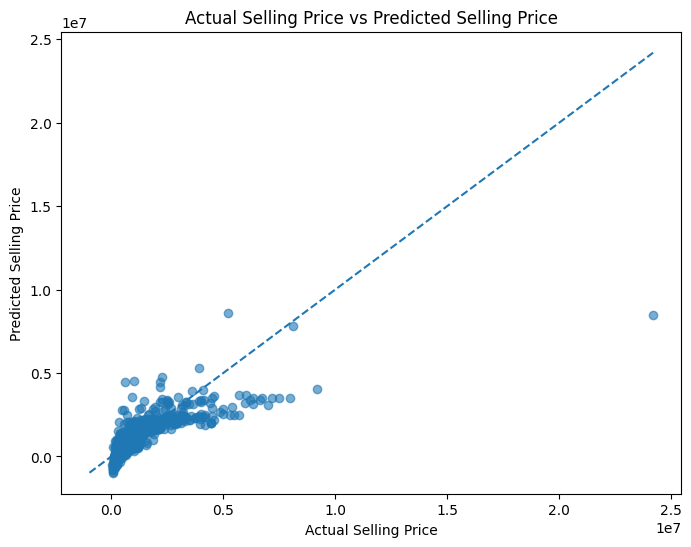

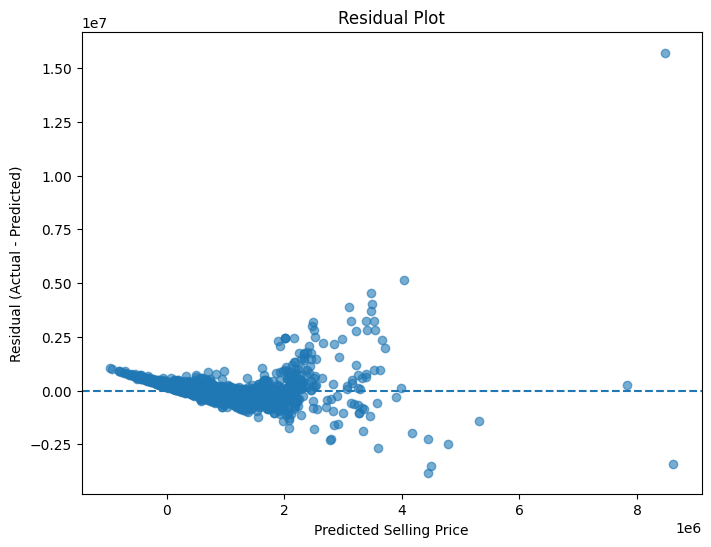

10 Observations with the Largest Prediction Errors:


,Actual_Price,Predicted_Price,Residual,Absolute_Error
2796,24200000.0,8.483885e+06,1.571612e+07,1.571612e+07
2362,9200000.0,4.036108e+06,5.163892e+06,5.163892e+06
1382,8000000.0,3.477296e+06,4.522704e+06,4.522704e+06
841,7500000.0,3.481968e+06,4.018032e+06,4.018032e+06
246,7000000.0,3.092218e+06,3.907782e+06,3.907782e+06
26,625000.0,4.449522e+06,-3.824522e+06,3.824522e+06
1286,7199000.0,3.477296e+06,3.721704e+06,3.721704e+06
2528,999000.0,4.497734e+06,-3.498734e+06,3.498734e+06
2050,5200000.0,8.617762e+06,-3.417762e+06,3.417762e+06
1092,6645000.0,3.388240e+06,3.256760e+06,3.256760e+06



Analysis:
1. Points close to the diagonal line indicate accurate predictions.
2. Points far from the diagonal line represent larger prediction errors.
3. The residuals should ideally be randomly scattered around zero.
4. Large residuals indicate observations that are difficult for the model to predict.
5. Possible reasons for prediction errors include car brand, condition,
   maintenance history, location, demand, accident history, and other
   factors that are not included in the dataset.


In [ ]:
# Task 19: Visualize and Analyze Model Performance

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calculate residuals
residuals = ytest - y_pred

# Find observations with the largest prediction errors
error_table = pd.DataFrame({
    "Actual_Price": ytest,
    "Predicted_Price": y_pred,
    "Residual": residuals,
    "Absolute_Error": np.abs(residuals)
})

large_errors = error_table.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

# ---------------------------------------------------------
# Plot 1: Actual vs Predicted Selling Price
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(ytest, y_pred, alpha=0.6)

# Perfect prediction reference line
min_price = min(ytest.min(), y_pred.min())
max_price = max(ytest.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual Selling Price vs Predicted Selling Price")
plt.show()

# ---------------------------------------------------------
# Plot 2: Residual Plot
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

# ---------------------------------------------------------
# Display observations with largest errors
# ---------------------------------------------------------
print("10 Observations with the Largest Prediction Errors:")
display(large_errors)

# ---------------------------------------------------------
# Analysis
# ---------------------------------------------------------
print("\nAnalysis:")
print("1. Points close to the diagonal line indicate accurate predictions.")
print("2. Points far from the diagonal line represent larger prediction errors.")
print("3. The residuals should ideally be randomly scattered around zero.")
print("4. Large residuals indicate observations that are difficult for the model to predict.")
print("5. Possible reasons for prediction errors include car brand, condition,")
print("   maintenance history, location, demand, accident history, and other")
print("   factors that are not included in the dataset.")

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


In [ ]:
# ============================================================
# TASK 20: CONCLUSION
# ============================================================

# Create coefficient table
feature_names = [
    'Intercept',
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

coefficient_table = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': beta
})

# Remove intercept for feature comparison
feature_importance = coefficient_table.iloc[1:].copy()

# Calculate absolute coefficient
feature_importance['Absolute Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

# Sort by influence
feature_importance = feature_importance.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

print("Features Ranked by Relative Influence:")
display(feature_importance)

print("\nMost Influential Feature:")
print(feature_importance.iloc[0]['Feature'])

print(
    "Coefficient:",
    feature_importance.iloc[0]['Coefficient']
)


Features Ranked by Relative Influence:


,Feature,Coefficient,Absolute Coefficient
1,vehicle_age,-65014.779175,65014.779175
5,max_power,15754.377629,15754.377629
3,mileage,13753.057078,13753.057078
6,seats,857.129320,857.129320
4,engine,75.815851,75.815851
2,km_driven,-0.677550,0.677550



Most Influential Feature:
vehicle_age
Coefficient: -65014.77917516278


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.